# SA — Regresión Lineal Simple

**Materia:** Extracción de Conocimiento de Base de Datos
**Docente:** Filiberto Ruíz Hernández
**Alumno:** Mario Alberto Ramírez Martínez — Matrícula 2023371044
**Universidad:** Universidad Tecnológica de Querétaro — Ingeniería en Gestión de Desarrollo de Software
**Semestre:** 2026 — Fecha: 2026-08-07

---

## 1. Regresión sobre beisbol.csv

Ajustar un modelo de regresión lineal para predecir las carreras anotadas (runs) a partir de los turnos al bat (bateos) del conjunto beisbol.csv, evaluarlo y optimizarlo, y guardar el modelo obtenido.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE = "/home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2"
DATA = os.path.join(BASE, "data/raw")
IMG = os.path.join(BASE, "reporte/img")
MODELOS = os.path.join(BASE, "modelos")
os.makedirs(IMG, exist_ok=True)
os.makedirs(MODELOS, exist_ok=True)
print("Rutas listas: DATA =", DATA)

Rutas listas: DATA = /home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2/data/raw


## Justificación del algoritmo

Se elige **Regresión Lineal Simple** porque la variable objetivo `runs` es **continua** y existe un único predictor numérico (`bateos`). Es el modelo más simple e interpretable: permite leer directamente cuántas carreras adicionales produce cada turno al bat extra. Con solo 30 equipos, un modelo más complejo (árboles, redes) se sobreajustaría fácilmente; la regresión lineal ofrece una línea de base robusta y auditable. Como optimización se compara contra regresión polinomial de grados 2–4 mediante búsqueda de hiperparámetros.

In [2]:
import pandas as pd
df = pd.read_csv(os.path.join(DATA, "beisbol.csv"), index_col=0)
df.head()

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [3]:
print("Dimensiones:", df.shape)
print("\nTipos:\n", df.dtypes)
print("\nNulos:\n", df.isna().sum())
print("\nEstadísticos:\n", df.describe().round(2))

Dimensiones: (30, 3)

Tipos:
 equipos      str
bateos     int64
runs       int64
dtype: object

Nulos:
 equipos    0
bateos     0
runs       0
dtype: int64

Estadísticos:
         bateos    runs
count    30.00   30.00
mean   5523.50  693.60
std      79.87   82.48
min    5417.00  556.00
25%    5448.25  629.00
50%    5515.50  705.50
75%    5575.00  734.00
max    5710.00  875.00


### Comportamiento de los datos (dispersión)

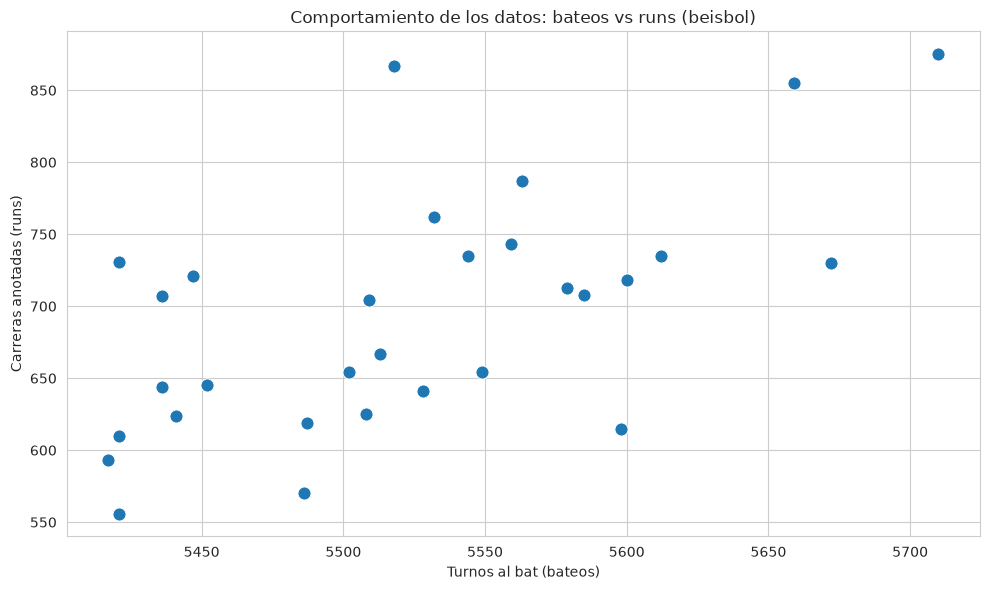

In [4]:
plt.figure()
sns.scatterplot(data=df, x="bateos", y="runs", s=90)
plt.title("Comportamiento de los datos: bateos vs runs (beisbol)")
plt.xlabel("Turnos al bat (bateos)")
plt.ylabel("Carreras anotadas (runs)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "scatter_beisbol.png"), dpi=150, bbox_inches="tight")
plt.show()

In [5]:
corr = df[["bateos", "runs"]].corr()
print("Correlación bateos-runs:", corr.loc["bateos", "runs"].round(4))

Correlación bateos-runs: 0.6106


## Diseño del modelo (paso a paso)

### Estrategia de evaluación con datos escasos

In [6]:
X = df[["bateos"]]
y = df["runs"]
# El conjunto tiene solo 30 observaciones y un predictor numérico.
# Reservar un test de 6-9 filas hace el R2 de prueba muy inestable
# (cambia drásticamente según la partición). Por ello se evalúa con
# validación cruzada (LOOCV y k-fold) usando RMSE, métrica bien
# definida incluso con pliegues de una sola muestra.
print("Observaciones:", X.shape[0], "| Predictor:", X.shape[1])

Observaciones: 30 | Predictor: 1


### Entrenamiento de la regresión lineal

In [7]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)
print("Pendiente (bateos -> runs):", round(modelo.coef_[0], 4))
print("Intercepto:", round(modelo.intercept_, 4))
print("Ecuación: runs = %.4f * bateos + %.4f" % (modelo.coef_[0], modelo.intercept_))

Pendiente (bateos -> runs): 0.6305
Intercepto: -2789.2429
Ecuación: runs = 0.6305 * bateos + -2789.2429


## Evaluación del modelo

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = modelo.predict(X)
print("--- AJUSTE COMPLETO (30 equipos) ---")
print("R2  :", round(r2_score(y, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y, y_pred)), 4))
print("MAE :", round(mean_absolute_error(y, y_pred), 4))

--- AJUSTE COMPLETO (30 equipos) ---
R2  : 0.3729
RMSE: 64.2189
MAE : 51.6674


In [9]:
from sklearn.model_selection import cross_val_score, LeaveOneOut

loocv = cross_val_score(modelo, X, y, cv=LeaveOneOut(), scoring="neg_root_mean_squared_error")
print("LOOCV RMSE (30 pliegues de 1 muestra):", round(-loocv.mean(), 4))
kfold = cross_val_score(modelo, X, y, cv=5, scoring="neg_root_mean_squared_error")
print("5-fold RMSE:", round(-kfold.mean(), 4), "| por pliegue:", (-kfold).round(2).tolist())

LOOCV RMSE (30 pliegues de 1 muestra): 55.5858
5-fold RMSE: 69.2297 | por pliegue: [84.98, 100.07, 32.61, 54.66, 73.84]


## Optimización — búsqueda de hiperparámetros (grado polinomial)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("poly", PolynomialFeatures()), ("lin", LinearRegression())])
grid = {"poly__degree": [1, 2, 3, 4]}
gs = GridSearchCV(pipe, grid, cv=5, scoring="neg_root_mean_squared_error")
gs.fit(X, y)
print("Mejor grado polinomial:", gs.best_params_)
print("Mejor RMSE (CV):", round(-gs.best_score_, 4))
res = pd.DataFrame(gs.cv_results_).sort_values("rank_test_score")
res = res.assign(rmse_cv=lambda d: (-d["mean_test_score"]).round(3))
print(res[["param_poly__degree", "rmse_cv"]].to_string(index=False))

Mejor grado polinomial: {'poly__degree': 3}
Mejor RMSE (CV): 68.9261
 param_poly__degree  rmse_cv
                  3   68.926
                  2   69.078
                  1   69.230
                  4   69.233


In [11]:
# Los grados 2-4 reducen el RMSE de validación en menos de 0.4 carreras (~0.5%)
# frente al grado 1, una mejora marginal que no justifica la complejidad añadida
# ni el riesgo de sobreajuste. Por parsimonia (principio de Occam), se conserva
# la regresión lineal simple (grado 1) como modelo final.
modelo_final = LinearRegression()
modelo_final.fit(X, y)
y_pred_final = modelo_final.predict(X)
print("Modelo final: regresión lineal simple (grado 1)")
print("R2 (ajuste completo):", round(r2_score(y, y_pred_final), 4))
print("RMSE (ajuste completo):", round(np.sqrt(mean_squared_error(y, y_pred_final)), 4))

Modelo final: regresión lineal simple (grado 1)
R2 (ajuste completo): 0.3729
RMSE (ajuste completo): 64.2189


### Gráfica comparativa: valores reales vs predichos

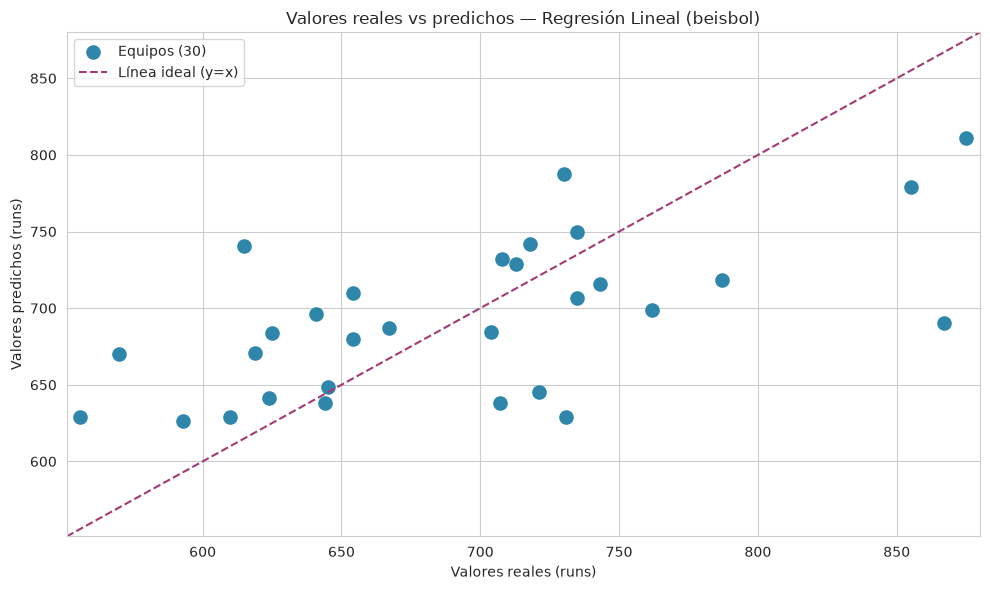

In [12]:
plt.figure()
plt.scatter(y, y_pred_final, s=90, color="#2E86AB", label="Equipos (30)")
lim = [y.min() - 5, y.max() + 5]
plt.plot(lim, lim, "--", color="#A23B72", label="Línea ideal (y=x)")
plt.xlim(lim); plt.ylim(lim)
plt.xlabel("Valores reales (runs)")
plt.ylabel("Valores predichos (runs)")
plt.title("Valores reales vs predichos — Regresión Lineal (beisbol)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG, "reales_predichos_beisbol.png"), dpi=150, bbox_inches="tight")
plt.show()

## Guardar el modelo

In [13]:
import joblib
joblib.dump(modelo_final, os.path.join(MODELOS, "beisbol_regresion_lineal.pkl"))
print("Modelo guardado en modelos/beisbol_regresion_lineal.pkl")

Modelo guardado en modelos/beisbol_regresion_lineal.pkl


## Verificación de integridad (recarga del modelo)

In [14]:
modelo_cargado = joblib.load(os.path.join(MODELOS, "beisbol_regresion_lineal.pkl"))
y_verif = modelo_cargado.predict(X)
print("R2 tras recargar:", round(r2_score(y, y_verif), 4))
print("Coincide con el modelo guardado:", np.allclose(y_verif, y_pred_final))

R2 tras recargar: 0.3729
Coincide con el modelo guardado: True
